# Tennis Doubles Homophily — Main Analysis

Data: Grand Slam doubles matches 2018–2025 (excl. 2020). N ≈ 1,795 matches after dropping retirements/walkovers.

Sections:
1. Variable construction
2. Pressure outcomes (tiebreaks, comebacks)
3. Olympic cycle descriptive evidence
4. Baseline regressions — match win / tiebreak win / comeback win

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import statsmodels.formula.api as smf
from getpass import getuser


pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)
pd.set_option('display.float_format', '{:.4f}'.format)

user = getuser()
df = pd.read_excel(f'C:/Users/{user}/Documents/GitHub/tennis-homophily/data/atp/men_matches_with_ranks_cleaned.xlsx')
print(f'Loaded {df.shape[0]:,} matches | years: {sorted(df["year"].unique())}')

Loaded 1,840 matches | years: [np.int64(2018), np.int64(2019), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


In [2]:
# ── Fix Olympic player nationality / language data ──────────────────────────
# ROC (Tokyo 2021) and AIN (Paris 2024) athletes competed as neutral but their
# nationalities are unambiguous. A few 2024 entries also have NaN country.
# Lebanon and Hungary have gaps in the language lookup (same_country=1, same_language=0).

_country_fixes = {
    'karatsev':       'Russia',
    'medvedev':       'Russia',
    'khachanov':      'Russia',
    'rublev':         'Russia',
    'safiullin':      'Russia',
    'gerasimov':      'Belarus',
    'ivashka':        'Belarus',
    'kubot':          'Poland',
    'paul':           'United States',
    'roger-vasselin': 'France',
    'balaji':         'India',
}

olym_idx = df[df['tournament'] == 'Olympics'].index

for prefix in ['winners_p1', 'winners_p2', 'losers_p1', 'losers_p2']:
    surname_col = f'{prefix}_surname'
    country_col = f'{prefix}_country'
    for surname, country in _country_fixes.items():
        fix = (
            df.index.isin(olym_idx) &
            df[surname_col].str.lower().str.strip().eq(surname) &
            df[country_col].isna()
        )
        df.loc[fix, country_col] = country

# Recompute same_country for Olympic rows only
df.loc[olym_idx, 'same_country_winners'] = (
    df.loc[olym_idx, 'winners_p1_country'] == df.loc[olym_idx, 'winners_p2_country']
).astype(float)
df.loc[olym_idx, 'same_country_losers'] = (
    df.loc[olym_idx, 'losers_p1_country'] == df.loc[olym_idx, 'losers_p2_country']
).astype(float)

# Fix same_language / ling_prox for Olympic same-country pairs where lookup was 0
# (covers both newly-fixed pairs and Lebanon/Hungary lookup gaps)
fix_w = df.index.isin(olym_idx) & df['same_country_winners'].eq(1) & df['winners_same_language'].eq(0)
fix_l = df.index.isin(olym_idx) & df['same_country_losers'].eq(1)  & df['losers_same_language'].eq(0)
df.loc[fix_w, ['winners_same_language', 'winners_linguistic_proximity']] = 1
df.loc[fix_l, ['losers_same_language',  'losers_linguistic_proximity']]  = 1

print(f'same_country_winners=0 remaining in Olympics: {(df.loc[olym_idx,"same_country_winners"]==0).sum()}')
print(f'same_country_losers=0  remaining in Olympics: {(df.loc[olym_idx,"same_country_losers"]==0).sum()}')
print(f'winners_same_language=0 remaining in Olympics: {(df.loc[olym_idx,"winners_same_language"]==0).sum()}')
print(f'losers_same_language=0  remaining in Olympics: {(df.loc[olym_idx,"losers_same_language"]==0).sum()}')

same_country_winners=0 remaining in Olympics: 0
same_country_losers=0  remaining in Olympics: 0
winners_same_language=0 remaining in Olympics: 0
losers_same_language=0  remaining in Olympics: 0


## 1. Variable Construction

In [3]:
# ── Tiebreak flags ─────────────────────────────────────────────────────────────
# Drop likely retirements/walkovers that are not explicitly flagged in the data.
# A valid completed set is 6-0 through 6-4, 7-5, 7-6, or an extended final set
# score with a two-game margin (e.g. 8-6, 9-7). If the first two sets are split,
# the third set must also be complete, either as a regular set or as a match tiebreak.
def regular_set_complete(w, l):
    valid = w.notna() & l.notna()
    hi = pd.concat([w, l], axis=1).max(axis=1)
    lo = pd.concat([w, l], axis=1).min(axis=1)
    return valid & (
        ((hi == 6) & (lo <= 4)) |
        ((hi == 7) & lo.isin([5, 6])) |
        ((hi >= 8) & ((hi - lo) == 2))
    )

def match_tiebreak_complete(w, l):
    valid = w.notna() & l.notna()
    hi = pd.concat([w, l], axis=1).max(axis=1)
    lo = pd.concat([w, l], axis=1).min(axis=1)
    return valid & (hi >= 10) & ((hi - lo) >= 2)

s1_complete = regular_set_complete(df['winners_set1'], df['losers_set1'])
s2_complete = regular_set_complete(df['winners_set2'], df['losers_set2'])
split_sets = (
    ((df['winners_set1'] > df['losers_set1']) & (df['winners_set2'] < df['losers_set2'])) |
    ((df['winners_set1'] < df['losers_set1']) & (df['winners_set2'] > df['losers_set2']))
)
s3_complete = (
    regular_set_complete(df['winners_set3'], df['losers_set3']) |
    match_tiebreak_complete(df['winners_set3'], df['losers_set3'])
)
retired_or_incomplete = ~s1_complete | ~s2_complete | (split_sets & ~s3_complete)
print(f'Dropping likely retirements/walkovers: {retired_or_incomplete.sum():,} matches')
df = df.loc[~retired_or_incomplete].copy()

# Regular 7-point tiebreak: set reaches 7-6
df['tb_s1'] = ((df['winners_set1']==7)&(df['losers_set1']==6)) | ((df['winners_set1']==6)&(df['losers_set1']==7))
df['tb_s2'] = ((df['winners_set2']==7)&(df['losers_set2']==6)) | ((df['winners_set2']==6)&(df['losers_set2']==7))
df['regular_tb']    = df['tb_s1'] | df['tb_s2']
df['tb_s3_regular'] = (((df['winners_set3']==7)&(df['losers_set3']==6)) | ((df['winners_set3']==6)&(df['losers_set3']==7))).fillna(False)

# Match tiebreak / super-tiebreak (10-point, set3 ≥ 10): Olympics and Wimbledon post-2018
df['match_tb'] = match_tiebreak_complete(df['winners_set3'], df['losers_set3'])
df['any_tb']   = df['regular_tb'] | df['match_tb'] | df['tb_s3_regular']

# Who won each tiebreak (winner-team perspective)
df['w_won_tb_s1'] = df['tb_s1'] & (df['winners_set1'] == 7)
df['w_won_tb_s2'] = df['tb_s2'] & (df['winners_set2'] == 7)

# ── Match structure ────────────────────────────────────────────────────────────
df['three_sets']     = df['winners_set3'].notna()
df['winner_lost_s1'] = df['winners_set1'] < df['losers_set1']
df['comeback']       = df['winner_lost_s1'] & df['three_sets']   # winner came back from 0-1 down

# ── Olympic period flags ───────────────────────────────────────────────────────
def get_period(row):
    y = row['year']
    t = row['tournament']
    if y in [2018, 2019]:
        return 'Pre-Tokyo'
    elif y == 2020:
        if t != 'Wimbledon':  # Exclude Wimbledon 2020
            return 'Tokyo Prep'
        else:
            return None  # Exclude Wimbledon 2020
    elif y == 2021:
        if t in ['Australian Open', 'Roland Garros', 'Wimbledon']:
            return 'Tokyo Prep'
        elif t == 'US Open':
            return 'Post-Tokyo'
    elif y == 2022:
        return 'Pre-Paris'
    elif y == 2023:
        return 'Paris Prep'
    elif y == 2024:
        if t in ['Australian Open', 'Roland Garros', 'Wimbledon']:
            return 'Paris Prep'
        elif t == 'US Open':
            return 'Post-Paris'
    elif y == 2025:
        return 'Post-Paris'
    return None

df['cycle'] = df.apply(get_period, axis=1)
df['pre_olympic']   = df['cycle'].isin(['Pre-Paris', 'Paris Prep']).astype(int)   # Pre-Paris and Paris Prep
df['olympic_period']= df['cycle'].isin(['Pre-Paris', 'Paris Prep', 'Post-Paris']).astype(int)
df['olympics_tourn']= (df['tournament'] == 'Olympics').astype(int)

# ── Match-level homophily differences (winner − loser) ────────────────────────
df['same_country_diff']  = df['same_country_winners'].astype(float)  - df['same_country_losers'].astype(float)
df['same_language_diff'] = df['winners_same_language'].astype(float) - df['losers_same_language'].astype(float)
df['ling_prox_diff']     = df['winners_linguistic_proximity'].astype(float) - df['losers_linguistic_proximity'].astype(float)

# Match-level averages (across both teams)

df['same_country_avg']   = (df['same_country_winners'] + df['same_country_losers']) / 2 
df['same_language_avg']  = (df['winners_same_language'] + df['losers_same_language']) / 2
df['ling_prox_avg']      = (df['winners_linguistic_proximity'] + df['losers_linguistic_proximity']) / 2
print('Variable construction complete.')

Dropping likely retirements/walkovers: 47 matches


Variable construction complete.


In [4]:
# ── Verify dropped matches ──────────────────────────────────────────────────────
# Each dropped match is classified as:
#   WALKOVER       : all set scores NaN (match never played)
#   RETIREMENT-S1  : set-2 score missing (retired during/after set 1)
#   RETIREMENT-S2+ : sets 1+2 complete but set-3 score missing (retired in set 3)
#   ABBREVIATED    : valid retirement/walkover where the player name uses only an
#                    initial (e.g. "A" from "A Ramos-Viñolas") — caught correctly
#                    by the score-completeness filter

def _classify_dropped(row):
    w1 = row.get("winners_set1")
    l1 = row.get("losers_set1")
    w2 = row.get("winners_set2")
    l2 = row.get("losers_set2")
    if pd.isna(w1) and pd.isna(l1):
        return "WALKOVER"
    if pd.notna(w1) and pd.notna(l1) and pd.notna(w2) and pd.notna(l2):
        return "RETIREMENT-S2+"
    return "RETIREMENT-S1"

df_full = pd.read_excel(
    f"C:/Users/{user}/Documents/GitHub/tennis-homophily/data/atp/men_matches_with_ranks_cleaned.xlsx",
    sheet_name="players_list"
)

def _s1c(w, l):
    valid = w.notna() & l.notna()
    hi = pd.concat([w, l], axis=1).max(axis=1)
    lo = pd.concat([w, l], axis=1).min(axis=1)
    return valid & (((hi==6)&(lo<=4))|((hi==7)&lo.isin([5,6]))|((hi>=8)&((hi-lo)==2)))

def _tb3(w, l):
    valid = w.notna() & l.notna()
    hi = pd.concat([w, l], axis=1).max(axis=1)
    lo = pd.concat([w, l], axis=1).min(axis=1)
    return valid & (hi >= 10) & ((hi - lo) >= 2)

_s1f = _s1c(df_full["winners_set1"], df_full["losers_set1"])
_s2f = _s1c(df_full["winners_set2"], df_full["losers_set2"])
_spf = (
    ((df_full["winners_set1"]>df_full["losers_set1"])&(df_full["winners_set2"]<df_full["losers_set2"])) |
    ((df_full["winners_set1"]<df_full["losers_set1"])&(df_full["winners_set2"]>df_full["losers_set2"]))
)
_s3f = _s1c(df_full["winners_set3"],df_full["losers_set3"]) | _tb3(df_full["winners_set3"],df_full["losers_set3"])
_ret_mask = ~_s1f | ~_s2f | (_spf & ~_s3f)

dropped_full = df_full[_ret_mask].copy()
dropped_full["drop_reason"] = dropped_full.apply(_classify_dropped, axis=1)

print(f"Total dropped: {len(dropped_full)}")
print(f"Full dataset rows: {len(df_full)}")
print()
print("=== Drop reasons ===")
print(dropped_full["drop_reason"].value_counts().to_string())
print()
print("=== WALKOVER ===")
wo = dropped_full[dropped_full["drop_reason"]=="WALKOVER"]
print(wo[["year","tournament","stage","winners_p1_name","winners_p2_name","losers_p1_name","losers_p2_name"]].to_string(index=False))
print()
print("=== Genuine retirements ===")
ret = dropped_full[dropped_full["drop_reason"].str.startswith("RETIREMENT")]
print(ret[["year","tournament","stage","drop_reason",
           "winners_p1_name","losers_p1_name",
           "winners_set1","losers_set1","winners_set2","losers_set2",
           "winners_set3","losers_set3"]].to_string(index=False))

Total dropped: 47
Full dataset rows: 1840

=== Drop reasons ===
drop_reason
WALKOVER          20
RETIREMENT-S2+    18
RETIREMENT-S1      9

=== WALKOVER ===
 year      tournament       stage winners_p1_name winners_p2_name losers_p1_name losers_p2_name
 2018 Australian Open Round of 32               j               f              n              m
 2018 Australian Open Round of 16               m           a-u-h              r              h
 2019         US Open Round of 32               r               d              m              a
 2019         US Open Round of 32               o               j              m              n
 2021        Olympics Round of 16          marcus         michael         wesley    jean-julien
 2021   Roland Garros Round of 16               r               f              m              m
 2021         US Open Round of 32               d               e              n              j
 2021       Wimbledon Round of 16               ł               m          

## 2. Pressure Outcomes — Counts and Inspection

In [5]:
print(f'=== Table 1. Pressure Outcome Counts (all matches, N={len(df):,}) ===')
rows = [
    ('Set-1 tiebreak (7-pt)',                          df['tb_s1']),
    ('Set-2 tiebreak (7-pt)',                          df['tb_s2']),
    ('Set-3 regular tiebreak (7-pt)',                  df['tb_s3_regular']),
    ('Match tiebreak / super-tb (10-pt, set3 ≥ 8)',   df['match_tb']),
    ('Any regular tiebreak (sets 1 or 2)',             df['regular_tb']),
    ('Any tiebreak (all types)',                       df['any_tb']),
    ('Match went to 3 sets',                           df['three_sets']),
    ('Comeback wins (winner lost set 1)',               df['comeback']),
]
for lbl, s in rows:
    print(f'  {lbl:<50s}  N={int(s.sum()):4d}  ({100*s.mean():.1f}%)')

print()
print('Regular tiebreaks by tournament:')
print(df.groupby('tournament')['regular_tb'].agg(['sum','mean']).rename(columns={'sum':'N','mean':'Rate'}).round(3).to_string())

print()
print('Match tiebreaks (super-tb) by tournament/year:')
print(df[df['match_tb']].groupby(['tournament','year']).size().to_frame('N').to_string())

print()
print('Comeback wins by tournament:')
print(df.groupby('tournament')['comeback'].agg(['sum','mean']).rename(columns={'sum':'N','mean':'Rate'}).round(3).to_string())

=== Table 1. Pressure Outcome Counts (all matches, N=1,793) ===
  Set-1 tiebreak (7-pt)                               N= 445  (24.8%)
  Set-2 tiebreak (7-pt)                               N= 470  (26.2%)
  Set-3 regular tiebreak (7-pt)                       N= 195  (10.9%)
  Match tiebreak / super-tb (10-pt, set3 ≥ 8)         N=  24  (1.3%)
  Any regular tiebreak (sets 1 or 2)                  N= 804  (44.8%)
  Any tiebreak (all types)                            N= 896  (50.0%)
  Match went to 3 sets                                N= 787  (43.9%)
  Comeback wins (winner lost set 1)                   N= 351  (19.6%)

Regular tiebreaks by tournament:
                   N   Rate
tournament                 
Australian Open  197 0.4590
Olympics          28 0.4440
Roland Garros    148 0.3440
US Open          206 0.4760
Wimbledon        225 0.5140

Match tiebreaks (super-tb) by tournament/year:
                  N
tournament year    
Olympics   2021   9
           2024  11
Wimbledon  2018   1

### 2.1 Tiebreak types treated together vs separately

Regular tiebreaks (7-point, in sets 1-2) and match tiebreaks (10-point super-tiebreak, set 3) measure the same underlying construct — pressure in a closely contested set — but with different point thresholds. For regression purposes we treat them together as `any_tb`. Match tiebreaks are few (N=30) and concentrated in the Olympics and Wimbledon.

## 3. Olympic Cycle Descriptive Evidence


In [6]:
gs = df[df['olympics_tourn'] == 0].copy()   # Grand Slams only

hcols = ['same_country_avg', 'same_language_avg', 'ling_prox_avg']

def assign_tokyo_cycle(row):
    y = row['year']
    t = row['tournament']
    if y in [2018, 2019]:
        return 'Pre-Tokyo'
    if y == 2020:
        return 'Tokyo Prep' if t != 'Wimbledon' else None
    if y == 2021:
        if t in ['Australian Open', 'Roland Garros', 'Wimbledon']:
            return 'Tokyo Prep'
        if t == 'US Open':
            return 'Post-Tokyo'
    if y == 2022:
        return 'Post-Tokyo'
    return None


def assign_paris_cycle(row):
    y = row['year']
    t = row['tournament']

    if y == 2022:
        return 'Pre-Paris'

    if y == 2023:
        if t in ['Australian Open', 'Roland Garros', 'Wimbledon', 'US Open']:
            return 'Paris Prep'

    if y == 2024:
        if t in ['Australian Open', 'Roland Garros', 'Wimbledon']:
            return 'Paris Prep'
        if t == 'US Open':
            return 'Post-Paris'

    if y == 2025:
        return 'Post-Paris'

    return None

gs['cycle_tokyo'] = gs.apply(assign_tokyo_cycle, axis=1)
gs['cycle_paris'] = gs.apply(assign_paris_cycle, axis=1)

cycle_order_tokyo = ['Pre-Tokyo', 'Tokyo Prep', 'Post-Tokyo']
cycle_order_paris = ['Pre-Paris', 'Paris Prep', 'Post-Paris']

panel_tokyo = pd.DataFrame({
    'Period': cycle_order_tokyo,
    'Calendar window': ['Jan 2018 – Dec 2019', 'Jan 2020 – Jul 2021', 'Aug 2021 – Dec 2022'],
    'GS included': ['AO18–USO19', 'AO20–Wim21 (ex Wim20)', 'USO21–USO22'],
}).set_index('Period')

panel_paris = pd.DataFrame({
    'Period': cycle_order_paris,
    'Calendar window': ['Jan 2022 – Dec 2022', 'Jan 2023 – Jul 2024', 'Aug 2024 – Dec 2025'],
    'GS included': ['AO22–USO22', 'AO23–Wim24', 'USO24–USO25'],
}).set_index('Period')

by_tokyo = gs[gs['cycle_tokyo'].notna()].groupby('cycle_tokyo')[hcols].mean().reindex(cycle_order_tokyo) * 100
by_tokyo.columns = ['Same Nationality', 'Same Language', 'Ling. Proximity']
by_tokyo['N teams'] = gs[gs['cycle_tokyo'].notna()].groupby('cycle_tokyo').size().reindex(cycle_order_tokyo) * 2

by_paris = gs[gs['cycle_paris'].notna()].groupby('cycle_paris')[hcols].mean().reindex(cycle_order_paris) * 100
by_paris.columns = ['Same Nationality', 'Same Language', 'Ling. Proximity']
by_paris['N teams'] = gs[gs['cycle_paris'].notna()].groupby('cycle_paris').size().reindex(cycle_order_paris) * 2

panel_tokyo = panel_tokyo.join(by_tokyo)
panel_paris = panel_paris.join(by_paris)

print('=== Table 2A. Tokyo 2021 cycle — Same nat/lang/langprox by period ===')
print(panel_tokyo.round({'Same Nationality':1,'Same Language':1,'Ling. Proximity':1}).to_string())

print()
print('=== Table 2B. Paris 2024 cycle — Same nat/lang/langprox by period ===')
print(panel_paris.round({'Same Nationality':1,'Same Language':1,'Ling. Proximity':1}).to_string())

print()
print('Overall same vs. diff homophily rates (Grand Slams, all teams):')
for avg_col, lbl in [
    ('same_country_avg',  'Same nationality'),
    ('same_language_avg', 'Same language'),
    ('ling_prox_avg',     'Ling. proximity'),
]:
    same_pct = 100 * gs[avg_col].mean()
    print(f'  {lbl:<25s}  Same={same_pct:.1f}%  Diff={(100-same_pct):.1f}%')

=== Table 2A. Tokyo 2021 cycle — Same nat/lang/langprox by period ===
                Calendar window            GS included  Same Nationality  Same Language  Ling. Proximity  N teams
Period                                                                                                           
Pre-Tokyo   Jan 2018 – Dec 2019             AO18–USO19           40.8000        55.0000          55.8000     1006
Tokyo Prep  Jan 2020 – Jul 2021  AO20–Wim21 (ex Wim20)           42.2000        56.1000          56.1000      364
Post-Tokyo  Aug 2021 – Dec 2022            USO21–USO22           39.8000        54.8000          55.5000      604

=== Table 2B. Paris 2024 cycle — Same nat/lang/langprox by period ===
                Calendar window  GS included  Same Nationality  Same Language  Ling. Proximity  N teams
Period                                                                                                 
Pre-Paris   Jan 2022 – Dec 2022   AO22–USO22           40.2000        54.2000    

In [7]:
# Same vs. diff homophily by year and tournament
avg_cols = ['same_country_avg', 'same_language_avg', 'ling_prox_avg']
by_year_tourn = gs.groupby(['year', 'tournament'])[avg_cols].mean() * 100
by_year_tourn.columns = ['Same Nationality (%)', 'Same Language (%)', 'Ling. Proximity (%)']
by_year_tourn['Diff Nationality (%)'] = 100 - by_year_tourn['Same Nationality (%)']
by_year_tourn['Diff Language (%)'] = 100 - by_year_tourn['Same Language (%)']
by_year_tourn['Diff Ling. Proximity (%)'] = 100 - by_year_tourn['Ling. Proximity (%)']
by_year_tourn = by_year_tourn[['Same Nationality (%)', 'Diff Nationality (%)',
                                'Same Language (%)', 'Diff Language (%)',
                                'Ling. Proximity (%)', 'Diff Ling. Proximity (%)']]
print('=== Table 2C. Same vs. Diff homophily by year and tournament (Grand Slams only) ===')
print(by_year_tourn.round(1).to_string())

=== Table 2C. Same vs. Diff homophily by year and tournament (Grand Slams only) ===
                      Same Nationality (%)  Diff Nationality (%)  Same Language (%)  Diff Language (%)  Ling. Proximity (%)  Diff Ling. Proximity (%)
year tournament                                                                                                                                      
2018 Australian Open               38.5000               61.5000            53.1000            46.9000              54.2000                   45.8000
     Roland Garros                 43.1000               56.9000            56.0000            44.0000              59.5000                   40.5000
     US Open                       37.7000               62.3000            51.6000            48.4000              51.6000                   48.4000
     Wimbledon                     30.0000               70.0000            51.5000            48.5000              51.5000                   48.5000
2019 Australian 

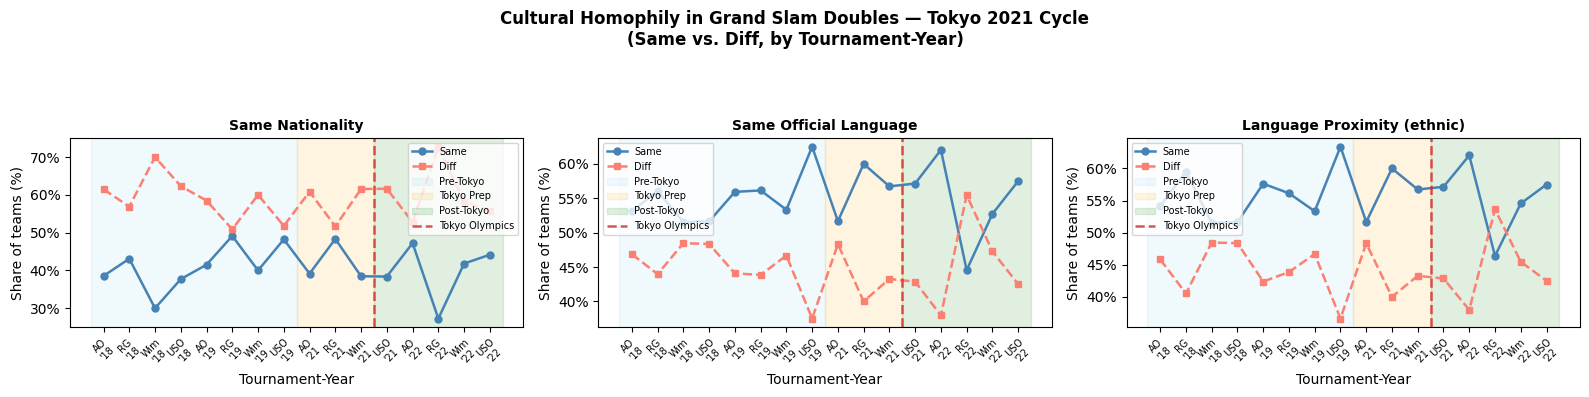

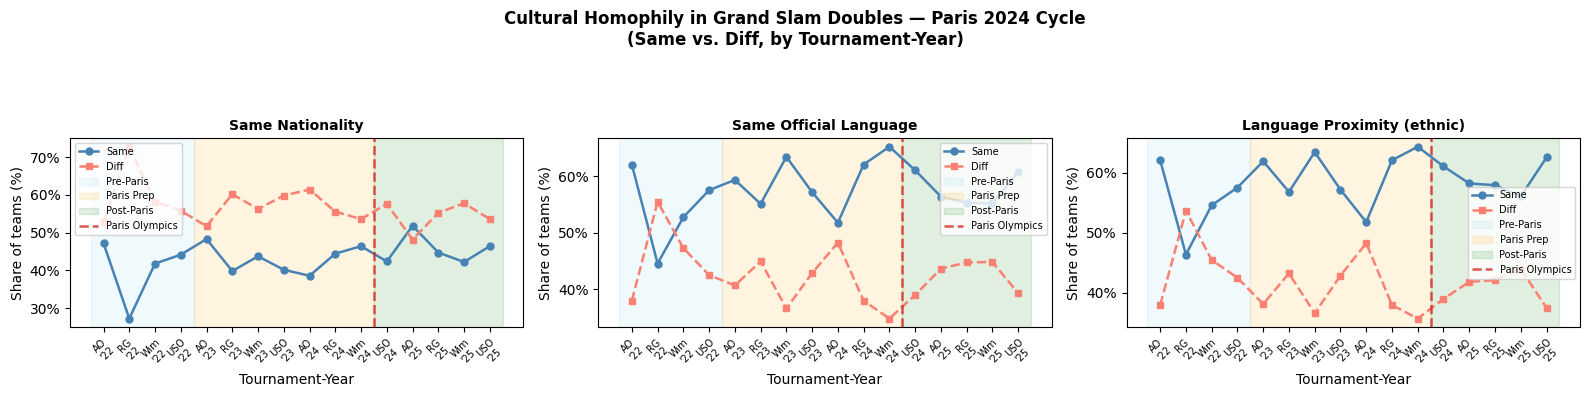

In [8]:
TOURN_ORDER = {'Australian Open': 0, 'Roland Garros': 1, 'Wimbledon': 2, 'US Open': 3}
TOURN_ABBR  = {'Australian Open': 'AO', 'Roland Garros': 'RG', 'Wimbledon': 'Wim', 'US Open': 'USO'}

avg_cols = ['same_country_avg', 'same_language_avg', 'ling_prox_avg']
titles   = ['Same Nationality', 'Same Official Language', 'Language Proximity (ethnic)']

# Chronologically-ordered tournament-year means
ty = gs.groupby(['year', 'tournament'])[avg_cols].mean().mul(100).reset_index()
ty['t_order'] = ty['tournament'].map(TOURN_ORDER)
ty = ty.sort_values(['year', 't_order']).reset_index(drop=True)
ty['label'] = ty.apply(lambda r: f"{TOURN_ABBR[r['tournament']]}\n'{str(r['year'])[2:]}", axis=1)

# ── Tokyo cycle ────────────────────────────────────────────────────────────────
ty_t = ty[ty['year'].isin([2018, 2019, 2021, 2022])].reset_index(drop=True)
ty_t['x'] = ty_t.index

pre_t  = ty_t['year'].isin([2018, 2019])
prep_t = (ty_t['year'] == 2021) & ty_t['tournament'].isin(['Australian Open', 'Roland Garros', 'Wimbledon'])
post_t = ((ty_t['year'] == 2021) & (ty_t['tournament'] == 'US Open')) | (ty_t['year'] == 2022)

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)
for ax, ac, ttl in zip(axes, avg_cols, titles):
    ax.plot(ty_t['x'], ty_t[ac],       marker='o', color='steelblue', lw=1.8, ms=5, label='Same')
    ax.plot(ty_t['x'], 100-ty_t[ac],   marker='s', color='salmon',    lw=1.8, ms=5, ls='--', label='Diff')
    for mask, color, lbl in [(pre_t, 'skyblue', 'Pre-Tokyo'), (prep_t, 'orange', 'Tokyo Prep'), (post_t, 'green', 'Post-Tokyo')]:
        xs = ty_t.loc[mask, 'x']
        if not xs.empty:
            ax.axvspan(xs.min() - 0.5, xs.max() + 0.5, alpha=0.12, color=color, label=lbl)
    x_wim = ty_t.loc[(ty_t['year'] == 2021) & (ty_t['tournament'] == 'Wimbledon'), 'x']
    x_uso = ty_t.loc[(ty_t['year'] == 2021) & (ty_t['tournament'] == 'US Open'),   'x']
    if not x_wim.empty and not x_uso.empty:
        ax.axvline((x_wim.values[0] + x_uso.values[0]) / 2,
                   color='#d62728', ls='--', lw=1.8, alpha=0.8, label='Tokyo Olympics')
    ax.set_title(ttl, fontsize=10, fontweight='bold')
    ax.set_xlabel('Tournament-Year'); ax.set_ylabel('Share of teams (%)')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
    ax.set_xticks(ty_t['x']); ax.set_xticklabels(ty_t['label'], fontsize=7)
    ax.tick_params(axis='x', rotation=45); ax.legend(fontsize=7)

fig.suptitle('Cultural Homophily in Grand Slam Doubles — Tokyo 2021 Cycle\n(Same vs. Diff, by Tournament-Year)',
             fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.savefig('../../ppt/homophily_tokyo_cycle.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Paris cycle ────────────────────────────────────────────────────────────────
ty_p = ty[ty['year'].isin([2022, 2023, 2024, 2025])].reset_index(drop=True)
ty_p['x'] = ty_p.index

pre_p  = ty_p['year'] == 2022
prep_p = (ty_p['year'] == 2023) | ((ty_p['year'] == 2024) & ty_p['tournament'].isin(['Australian Open', 'Roland Garros', 'Wimbledon']))
post_p = ((ty_p['year'] == 2024) & (ty_p['tournament'] == 'US Open')) | (ty_p['year'] == 2025)

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)
for ax, ac, ttl in zip(axes, avg_cols, titles):
    ax.plot(ty_p['x'], ty_p[ac],       marker='o', color='steelblue', lw=1.8, ms=5, label='Same')
    ax.plot(ty_p['x'], 100-ty_p[ac],   marker='s', color='salmon',    lw=1.8, ms=5, ls='--', label='Diff')
    for mask, color, lbl in [(pre_p, 'skyblue', 'Pre-Paris'), (prep_p, 'orange', 'Paris Prep'), (post_p, 'green', 'Post-Paris')]:
        xs = ty_p.loc[mask, 'x']
        if not xs.empty:
            ax.axvspan(xs.min() - 0.5, xs.max() + 0.5, alpha=0.12, color=color, label=lbl)
    x_wim = ty_p.loc[(ty_p['year'] == 2024) & (ty_p['tournament'] == 'Wimbledon'), 'x']
    x_uso = ty_p.loc[(ty_p['year'] == 2024) & (ty_p['tournament'] == 'US Open'),   'x']
    if not x_wim.empty and not x_uso.empty:
        ax.axvline((x_wim.values[0] + x_uso.values[0]) / 2,
                   color='#d62728', ls='--', lw=1.8, alpha=0.8, label='Paris Olympics')
    ax.set_title(ttl, fontsize=10, fontweight='bold')
    ax.set_xlabel('Tournament-Year'); ax.set_ylabel('Share of teams (%)')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
    ax.set_xticks(ty_p['x']); ax.set_xticklabels(ty_p['label'], fontsize=7)
    ax.tick_params(axis='x', rotation=45); ax.legend(fontsize=7)

fig.suptitle('Cultural Homophily in Grand Slam Doubles — Paris 2024 Cycle\n(Same vs. Diff, by Tournament-Year)',
             fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.savefig('../../ppt/homophily_paris_cycle.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Team Panel Construction

Convert match-level data to team-level panel: each match creates 2 observations (winners=1, losers=0).


In [9]:
# Build team panel (match-level → team-level: winners row + losers row)
match_vars = ['match_id','tournament','year','surface','stage_code','any_tb','regular_tb','match_tb','tb_s3_regular',
              'three_sets','comeback','winner_lost_s1','pre_olympic','olympic_period','olympics_tourn']

# Winners row
w_row = df[match_vars].copy()
for col, src in [('same_country','same_country_winners'),('same_language','winners_same_language'),
                 ('ling_prox','winners_linguistic_proximity'),('rank_mean','rank_mean_winners'),
                 ('wl_career_diff','wl_career_diff_winners'),('rank_gap','rank_diff_winners')]:
    w_row[col] = df[src].values
w_row['single_top100'] = ((df['winners_p1_top100_within_1y']==1) | (df['winners_p2_top100_within_1y']==1)).astype(int)
w_row['win'] = 1
w_row['won_tb_s1'] = df['w_won_tb_s1'].values
w_row['won_tb_s2'] = df['w_won_tb_s2'].values

# Losers row
l_row = df[match_vars].copy()
for col, src in [('same_country','same_country_losers'),('same_language','losers_same_language'),
                 ('ling_prox','losers_linguistic_proximity'),('rank_mean','rank_mean_losers'),
                 ('wl_career_diff','wl_career_diff_losers'),('rank_gap','rank_diff_losers')]:
    l_row[col] = df[src].values
l_row['single_top100'] = ((df['losers_p1_top100_within_1y']==1) | (df['losers_p2_top100_within_1y']==1)).astype(int)
l_row['win'] = 0
l_row['won_tb_s1'] = (df['tb_s1'] & (df['winners_set1']==6)).values
l_row['won_tb_s2'] = (df['tb_s2'] & (df['winners_set2']==6)).values

# Concatenate and compute derived variables
team_df = pd.concat([w_row, l_row], ignore_index=True)
team_df['opp_rank_mean'] = team_df.groupby('match_id')['rank_mean'].transform('sum') - team_df['rank_mean']
team_df['stage_code'] = team_df['stage_code'].fillna(-1).astype(int)
team_df['lost_set1'] = np.where(team_df['win']==1, team_df['winner_lost_s1'], ~team_df['winner_lost_s1'])
team_df['comeback'] = (team_df['win'] & team_df['lost_set1']).astype(int)

# Convert booleans to int
for col in team_df.columns:
    if str(team_df[col].dtype) in ('bool','boolean','Int64','Int32'):
        team_df[col] = team_df[col].fillna(0).astype(int)

# ── Drop entire matches with incomplete data (user requirement) ────────────────
# Rule 1: ranking — drop both team-obs for any match where either team has NaN rank_mean
#         (rank_mean = NaN means BOTH players on that team are unranked in the doubles file)
bad_rank = set(team_df.loc[team_df['rank_mean'].isna(), 'match_id'])

# Rule 2: nationality / language — drop both team-obs for any match where either team's
#         same_country / same_language / ling_prox is NaN (player country unknown)
bad_nat = set(
    team_df.loc[team_df[['same_country','same_language','ling_prox']].isna().any(axis=1), 'match_id']
)

bad_matches = bad_rank | bad_nat
n_rank = len(bad_rank)
n_nat  = len(bad_nat - bad_rank)  # nat-only bad matches

team_df = team_df[~team_df['match_id'].isin(bad_matches)].reset_index(drop=True)

print(f'Team panel constructed: {len(team_df):,} obs | {team_df["match_id"].nunique():,} matches')
print(f'  Dropped {n_rank} matches: ranking incomplete (both players on one team unranked)')
print(f'  Dropped {n_nat} matches: nationality/language data missing for at least one player')
print(f'  Total matches dropped: {len(bad_matches)}')

Team panel constructed: 3,300 obs | 1,650 matches
  Dropped 14 matches: ranking incomplete (both players on one team unranked)
  Dropped 129 matches: nationality/language data missing for at least one player
  Total matches dropped: 143


## 4. Baseline Regressions

Each match contributes **two** observations (winner team = 1, loser team = 0).  
Each culture measure (`same_country`, `same_language`, `ling_prox`) is entered one at a time.  
Controls: team average doubles ranking, opponent ranking, teammate rank gap, top-100 singles indicator.  
Fixed effects: tournament-by-year interaction, round (stage_code).  
Standard errors clustered by match.

In [10]:
# Grand Slams panel (Olympics excluded)
# Cell 14 already dropped incomplete-ranking and incomplete-nationality matches from team_df
team_gs = team_df[team_df['olympics_tourn'] == 0].dropna(subset=['rank_mean', 'rank_gap']).copy()
team_gs['won_regular_tb'] = ((team_gs['won_tb_s1'] == 1) | (team_gs['won_tb_s2'] == 1)).astype(int)
team_gs['won_any_tb'] = ((team_gs['won_tb_s1'] == 1) | (team_gs['won_tb_s2'] == 1) |
                         (team_gs['match_tb'] == 1) | (team_gs['tb_s3_regular'] == 1)).astype(int)

gs_matches = team_gs['match_id'].nunique()
mc = team_gs.groupby('match_id').size()
print(f'Team panel (Grand Slams only): {len(team_gs):,} obs | {gs_matches:,} unique matches')
print(f'  Complete pairs (2 obs): {(mc==2).sum():,}  |  Singleton obs (rank or nat/lang incomplete): {(mc==1).sum():,}')

# Panel including Olympics
team_all = team_df.dropna(subset=['rank_mean', 'rank_gap']).copy()
team_all['won_regular_tb'] = ((team_all['won_tb_s1'] == 1) | (team_all['won_tb_s2'] == 1)).astype(int)
team_all['won_any_tb'] = ((team_all['won_tb_s1'] == 1) | (team_all['won_tb_s2'] == 1) |
                          (team_all['match_tb'] == 1) | (team_all['tb_s3_regular'] == 1)).astype(int)
print(f'Team panel (incl. Olympics):   {len(team_all):,} obs | {team_all["match_id"].nunique():,} unique matches')

Team panel (Grand Slams only): 3,196 obs | 1,598 unique matches
  Complete pairs (2 obs): 1,598  |  Singleton obs (rank or nat/lang incomplete): 0
Team panel (incl. Olympics):   3,300 obs | 1,650 unique matches


In [11]:
output_gs  = f'C:/Users/{user}/Documents/GitHub/tennis-homophily/data/atp/team_gs_panel.csv'
output_all = f'C:/Users/{user}/Documents/GitHub/tennis-homophily/data/atp/team_all_panel.csv'
team_gs.to_csv(output_gs,  index=False)
team_all.to_csv(output_all, index=False)
print(f'Grand Slams panel saved to {output_gs}')
print(f'Full panel (incl. Olympics) saved to {output_all}')

Grand Slams panel saved to C:/Users/ALESSANDRO/Documents/GitHub/tennis-homophily/data/atp/team_gs_panel.csv
Full panel (incl. Olympics) saved to C:/Users/ALESSANDRO/Documents/GitHub/tennis-homophily/data/atp/team_all_panel.csv


In [12]:
FE = '+ C(tournament):C(year) + C(stage_code)'

CULTURE_VARS = [
    ('same_country',  'Same nationality'),
    ('same_language', 'Same official language'),
    ('ling_prox',     'Language proximity (ethnic)'),
]

CONTROLS = 'rank_mean + opp_rank_mean + rank_gap + single_top100'

ctrl_vars = [
    ('rank_mean',      'Team avg doubles ranking'),
    ('opp_rank_mean',  'Opponent avg doubles ranking'),
    ('rank_gap',       'Teammate rank gap'),
    ('single_top100',  'Top-100 singles player'),
]

def show_vars(res, var_list, prefix=''):
    for v, lbl in var_list:
        if v not in res.params:
            continue
        c, se, p = res.params[v], res.bse[v], res.pvalues[v]
        stars = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.10 else ''
        print(f'  {prefix}{lbl:<42s}  {c:+.4f}{stars:<3s}  se={se:.4f}  p={p:.3f}')

In [13]:
print('=== Table 3. Match Win — Logit ===')
print('FE: tournament×year + round | SE clustered by match | Sample: Grand Slams only')

for cvar, clbl in CULTURE_VARS:
    res = smf.logit(f'win ~ {cvar} + {CONTROLS} {FE}', data=team_gs).fit(
        cov_type='cluster', cov_kwds={'groups': team_gs['match_id']}, disp=False)
    print(f'\n  [{clbl}]  N={int(res.nobs):,}  Pseudo-R²={res.prsquared:.3f}')
    show_vars(res, [(cvar, clbl)] + ctrl_vars)

=== Table 3. Match Win — Logit ===
FE: tournament×year + round | SE clustered by match | Sample: Grand Slams only



  [Same nationality]  N=3,196  Pseudo-R²=0.092
  Same nationality                            +0.0577     se=0.0791  p=0.466
  Team avg doubles ranking                    -0.0041***  se=0.0006  p=0.000


  Opponent avg doubles ranking                +0.0033***  se=0.0003  p=0.000
  Teammate rank gap                           +0.0008     se=0.0005  p=0.107
  Top-100 singles player                      +0.0825     se=0.1515  p=0.586

  [Same official language]  N=3,196  Pseudo-R²=0.093
  Same official language                      +0.1163     se=0.0765  p=0.129
  Team avg doubles ranking                    -0.0041***  se=0.0006  p=0.000
  Opponent avg doubles ranking                +0.0033***  se=0.0003  p=0.000


  Teammate rank gap                           +0.0008     se=0.0005  p=0.109
  Top-100 singles player                      +0.0823     se=0.1518  p=0.588



  [Language proximity (ethnic)]  N=3,196  Pseudo-R²=0.093
  Language proximity (ethnic)                 +0.0968     se=0.0765  p=0.205
  Team avg doubles ranking                    -0.0041***  se=0.0006  p=0.000
  Opponent avg doubles ranking                +0.0033***  se=0.0003  p=0.000
  Teammate rank gap                           +0.0008     se=0.0005  p=0.110
  Top-100 singles player                      +0.0840     se=0.1517  p=0.580


In [14]:
print('=== Table 4. Tiebreak Win — Logit ===')
print('FE: tournament×year + round | SE clustered by match | Sample: Grand Slams only')

# ── (A) Primary: 7-point regular tiebreaks only (sets 1 or 2) ─────────────────
tb_reg = team_gs[team_gs['regular_tb'] == 1].copy()
tb_reg_matches = tb_reg['match_id'].nunique()
print(f'\n--- (A) 7-pt regular tiebreaks only (sets 1 or 2) ---')
print(f'N={len(tb_reg):,} team-obs | {tb_reg_matches:,} matches')

for cvar, clbl in CULTURE_VARS:
    res = smf.logit(f'won_regular_tb ~ {cvar} + {CONTROLS} {FE}', data=tb_reg).fit(
        cov_type='cluster', cov_kwds={'groups': tb_reg['match_id']}, disp=False)
    print(f'\n  [{clbl}]  N={int(res.nobs):,}  Pseudo-R²={res.prsquared:.3f}')
    show_vars(res, [(cvar, clbl)] + ctrl_vars)

# ── (B) Reference: any tiebreak (7-pt + 10-pt super-tb) ──────────────────────
tb_any = team_gs[team_gs['any_tb'] == 1].copy()
tb_any_matches = tb_any['match_id'].nunique()
print(f'\n--- (B) Any tiebreak (7-pt + 10-pt super-tb) — reference ---')
print(f'N={len(tb_any):,} team-obs | {tb_any_matches:,} matches')
print(f'  Note: {len(tb_any) - tb_any_matches*2 + tb_any_matches*2 - len(tb_any[tb_any.groupby("match_id")["match_id"].transform("count")==2]):,}'
      f' orphan obs (one team rank NaN in {(tb_any.groupby("match_id").size()==1).sum():,} matches)')

for cvar, clbl in CULTURE_VARS:
    res = smf.logit(f'won_any_tb ~ {cvar} + {CONTROLS} {FE}', data=tb_any).fit(
        cov_type='cluster', cov_kwds={'groups': tb_any['match_id']}, disp=False)
    print(f'\n  [{clbl}]  N={int(res.nobs):,}  Pseudo-R²={res.prsquared:.3f}')
    show_vars(res, [(cvar, clbl)] + ctrl_vars)

=== Table 4. Tiebreak Win — Logit ===
FE: tournament×year + round | SE clustered by match | Sample: Grand Slams only

--- (A) 7-pt regular tiebreaks only (sets 1 or 2) ---
N=1,424 team-obs | 712 matches



  [Same nationality]  N=1,424  Pseudo-R²=0.022
  Same nationality                            +0.1044     se=0.1199  p=0.384


  Team avg doubles ranking                    -0.0007     se=0.0006  p=0.205
  Opponent avg doubles ranking                +0.0012***  se=0.0004  p=0.001
  Teammate rank gap                           -0.0008     se=0.0006  p=0.156
  Top-100 singles player                      -0.4210*    se=0.2311  p=0.068

  [Same official language]  N=1,424  Pseudo-R²=0.022
  Same official language                      +0.0593     se=0.1162  p=0.610
  Team avg doubles ranking                    -0.0007     se=0.0006  p=0.231
  Opponent avg doubles ranking                +0.0012***  se=0.0004  p=0.001
  Teammate rank gap                           -0.0008     se=0.0006  p=0.147
  Top-100 singles player                      -0.4110*    se=0.2307  p=0.075



  [Language proximity (ethnic)]  N=1,424  Pseudo-R²=0.021
  Language proximity (ethnic)                 +0.0411     se=0.1160  p=0.723
  Team avg doubles ranking                    -0.0007     se=0.0006  p=0.238
  Opponent avg doubles ranking                +0.0012***  se=0.0004  p=0.001
  Teammate rank gap                           -0.0008     se=0.0006  p=0.146
  Top-100 singles player                      -0.4094*    se=0.2305  p=0.076

--- (B) Any tiebreak (7-pt + 10-pt super-tb) — reference ---
N=1,594 team-obs | 797 matches
  Note: 0 orphan obs (one team rank NaN in 0 matches)



  [Same nationality]  N=1,594  Pseudo-R²=0.025
  Same nationality                            +0.0243     se=0.1167  p=0.835
  Team avg doubles ranking                    -0.0007     se=0.0005  p=0.225
  Opponent avg doubles ranking                +0.0010***  se=0.0004  p=0.006
  Teammate rank gap                           -0.0005     se=0.0005  p=0.301
  Top-100 singles player                      -0.3917*    se=0.2150  p=0.068



  [Same official language]  N=1,594  Pseudo-R²=0.025
  Same official language                      +0.0228     se=0.1137  p=0.841
  Team avg doubles ranking                    -0.0007     se=0.0005  p=0.224
  Opponent avg doubles ranking                +0.0010***  se=0.0004  p=0.006
  Teammate rank gap                           -0.0005     se=0.0005  p=0.298
  Top-100 singles player                      -0.3904*    se=0.2150  p=0.069

  [Language proximity (ethnic)]  N=1,594  Pseudo-R²=0.025
  Language proximity (ethnic)                 +0.0012     se=0.1137  p=0.991
  Team avg doubles ranking                    -0.0006     se=0.0005  p=0.232
  Opponent avg doubles ranking                +0.0010***  se=0.0004  p=0.006
  Teammate rank gap                           -0.0005     se=0.0005  p=0.295
  Top-100 singles player                      -0.3893*    se=0.2148  p=0.070


In [15]:
print('=== Table 5. Comeback Win (Adversity Sample) — Logit ===')
print('Sample: all GS teams that lost set 1 — adversity scenarios:')
print('  0|1|1 = lost set 1, won sets 2+3 → comeback WIN')
print('  0|1|0 = lost set 1, won set 2, lost set 3 → no comeback')
print('  0|0   = lost set 1, lost set 2 → swept, no comeback')
print('Each match contributes exactly ONE observation (the team that lost set 1).')
print('Outcome: win=1 (comeback) or win=0 (any loss scenario).')
print('FE: tournament×year + round | SE: HC3 robust (1 obs/match, no within-match clustering)')

# Build adversity sample: one obs per match (the team that lost set 1)
cb_adv = team_gs[team_gs['lost_set1'] == 1].copy()

n_win  = cb_adv['win'].sum()
n_3s_l = ((cb_adv['three_sets'] == 1) & (cb_adv['win'] == 0)).sum()
n_2s_l = ((cb_adv['three_sets'] == 0) & (cb_adv['win'] == 0)).sum()
print(f'\nAdversity obs: {len(cb_adv):,}  (= {cb_adv["match_id"].nunique():,} matches)')
print(f'  0|1|1 comeback wins:       {n_win:,}  ({100*n_win/len(cb_adv):.1f}%)')
print(f'  0|1|0 3-set losses:        {n_3s_l:,}  ({100*n_3s_l/len(cb_adv):.1f}%)')
print(f'  0|0   straight-set losses: {n_2s_l:,}  ({100*n_2s_l/len(cb_adv):.1f}%)')

# Drop tournament-year cells with no within-cell variation in outcome (perfect prediction)
cb_adv['ty'] = cb_adv['tournament'].astype(str) + '__' + cb_adv['year'].astype(int).astype(str)
_ty_ok = cb_adv.groupby('ty')['win'].nunique()
cb_adv = cb_adv[cb_adv['ty'].isin(_ty_ok[_ty_ok == 2].index)].copy()
print(f'After dropping non-informative ty cells: N={len(cb_adv):,}')

for cvar, clbl in CULTURE_VARS:
    for fe_try, label in [
        ('+ C(ty) + C(stage_code)', 'ty FE + stage FE'),
        ('+ C(ty)', 'ty FE only'),
    ]:
        try:
            res = smf.logit(f'win ~ {cvar} + {CONTROLS} {fe_try}', data=cb_adv).fit(
                cov_type='HC3', disp=False, maxiter=200)
            print(f'\n  [{clbl}]  FE: {label}  |  N={int(res.nobs):,}  Pseudo-R²={res.prsquared:.3f}')
            show_vars(res, [(cvar, clbl)] + ctrl_vars)
            break
        except Exception as e:
            print(f'  [{clbl}] {label} failed: {e}')

=== Table 5. Comeback Win (Adversity Sample) — Logit ===
Sample: all GS teams that lost set 1 — adversity scenarios:
  0|1|1 = lost set 1, won sets 2+3 → comeback WIN
  0|1|0 = lost set 1, won set 2, lost set 3 → no comeback
  0|0   = lost set 1, lost set 2 → swept, no comeback
Each match contributes exactly ONE observation (the team that lost set 1).
Outcome: win=1 (comeback) or win=0 (any loss scenario).
FE: tournament×year + round | SE: HC3 robust (1 obs/match, no within-match clustering)

Adversity obs: 1,598  (= 1,598 matches)
  0|1|1 comeback wins:       310  (19.4%)
  0|1|0 3-set losses:        392  (24.5%)
  0|0   straight-set losses: 896  (56.1%)
After dropping non-informative ty cells: N=1,598



  [Same nationality]  FE: ty FE + stage FE  |  N=1,598  Pseudo-R²=0.065
  Same nationality                            -0.2350*    se=0.1366  p=0.085
  Team avg doubles ranking                    -0.0027***  se=0.0010  p=0.009
  Opponent avg doubles ranking                +0.0020***  se=0.0004  p=0.000
  Teammate rank gap                           +0.0001     se=0.0008  p=0.887
  Top-100 singles player                      -0.2028     se=0.2626  p=0.440


C:\Users\ALESSANDRO\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\ALESSANDRO\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



  [Same official language]  FE: ty FE + stage FE  |  N=1,598  Pseudo-R²=0.067
  Same official language                      -0.3243**   se=0.1324  p=0.014
  Team avg doubles ranking                    -0.0028***  se=0.0010  p=0.008
  Opponent avg doubles ranking                +0.0021***  se=0.0004  p=0.000
  Teammate rank gap                           +0.0001     se=0.0008  p=0.865
  Top-100 singles player                      -0.2025     se=0.2628  p=0.441



  [Language proximity (ethnic)]  FE: ty FE + stage FE  |  N=1,598  Pseudo-R²=0.067
  Language proximity (ethnic)                 -0.3301**   se=0.1325  p=0.013
  Team avg doubles ranking                    -0.0028***  se=0.0010  p=0.007
  Opponent avg doubles ranking                +0.0021***  se=0.0004  p=0.000
  Teammate rank gap                           +0.0002     se=0.0008  p=0.851
  Top-100 singles player                      -0.2062     se=0.2627  p=0.432


C:\Users\ALESSANDRO\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
